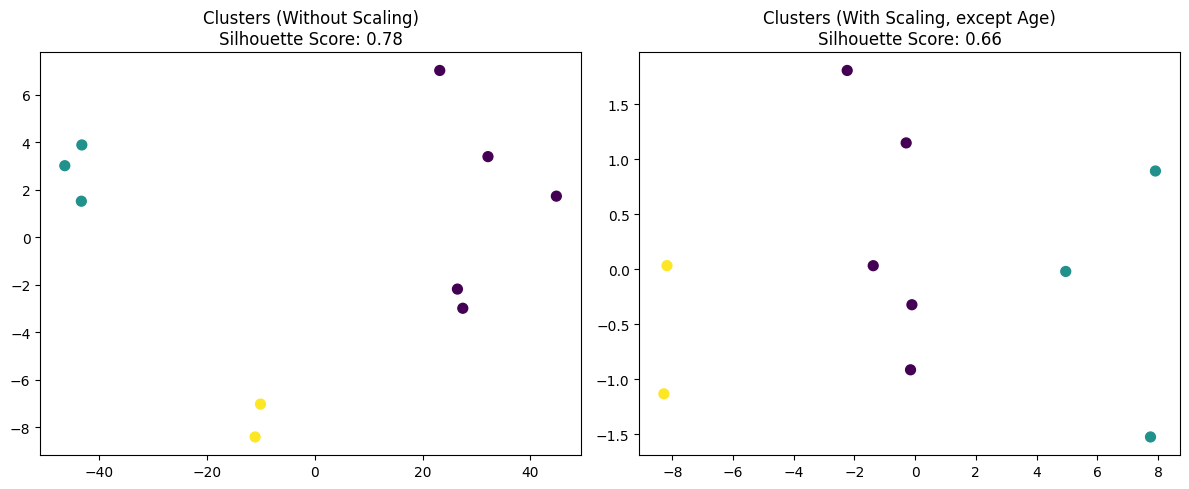

Silhouette Score without scaling: 0.78
Silhouette Score with partial scaling (except Age): 0.66

Clustering without scaling performed better or equally well.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

data = {
    'CustomerID': range(1, 11),
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Female', 'Male', 'Male', 'Female', 'Female', 'Male'],
    'Age': [19, 35, 26, 27, 19, 27, 27, 32, 25, 35],
    'Annual Income (k$)': [15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
    'Spending Score (1-100)': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72]
}

df = pd.DataFrame(data)
features = df.drop('CustomerID', axis=1)
features = pd.get_dummies(features, columns=['Gender'], drop_first=True)

X_unscaled = features.copy()
kmeans_unscaled = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels_unscaled = kmeans_unscaled.fit_predict(X_unscaled)
silhouette_unscaled = silhouette_score(X_unscaled, labels_unscaled)

X_scaled = features.copy()
scaler = StandardScaler()
cols_to_scale = ['Annual Income (k$)', 'Spending Score (1-100)']
X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

kmeans_scaled = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)
silhouette_scaled = silhouette_score(X_scaled, labels_scaled)

pca = PCA(n_components=2)
X_pca_unscaled = pca.fit_transform(X_unscaled)
X_pca_scaled = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_pca_unscaled[:, 0], X_pca_unscaled[:, 1], c=labels_unscaled, cmap='viridis', s=50)
plt.title('Clusters (Without Scaling)\nSilhouette Score: {:.2f}'.format(silhouette_unscaled))
plt.subplot(1, 2, 2)
plt.scatter(X_pca_scaled[:, 0], X_pca_scaled[:, 1], c=labels_scaled, cmap='viridis', s=50)
plt.title('Clusters (With Scaling, except Age)\nSilhouette Score: {:.2f}'.format(silhouette_scaled))
plt.tight_layout()
plt.show()

print("Silhouette Score without scaling:", round(silhouette_unscaled, 2))
print("Silhouette Score with partial scaling (except Age):", round(silhouette_scaled, 2))

if silhouette_scaled > silhouette_unscaled:
    print("\nScaling (except Age) led to better-defined clusters.")
else:
    print("\nClustering without scaling performed better or equally well.")


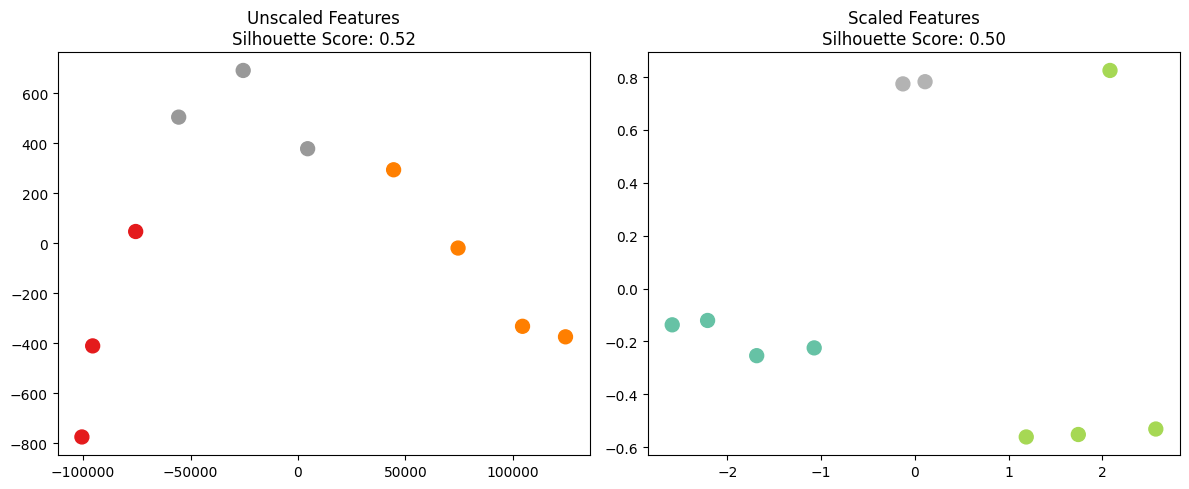

Silhouette Score (Unscaled): 0.52
Silhouette Score (Scaled): 0.5

Scaling had little or no positive effect on clustering.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Sample Data
data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)
df_encoded = pd.get_dummies(df, columns=['vehicle_type'], drop_first=True)

df_encoded = df_encoded.drop(columns=['vehicle_serial_no'])

X_unscaled = df_encoded.copy()
kmeans_unscaled = KMeans(n_clusters=3, random_state=42)
labels_unscaled = kmeans_unscaled.fit_predict(X_unscaled)
silhouette_unscaled = silhouette_score(X_unscaled, labels_unscaled)

X_scaled = df_encoded.copy()
features_to_scale = ['mileage', 'fuel_efficiency', 'maintenance_cost']
scaler = StandardScaler()
X_scaled[features_to_scale] = scaler.fit_transform(X_scaled[features_to_scale])

kmeans_scaled = KMeans(n_clusters=3, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)
silhouette_scaled = silhouette_score(X_scaled, labels_scaled)

pca = PCA(n_components=2)
X_pca_unscaled = pca.fit_transform(X_unscaled)
X_pca_scaled = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca_unscaled[:, 0], X_pca_unscaled[:, 1], c=labels_unscaled, cmap='Set1', s=100)
plt.title(f'Unscaled Features\nSilhouette Score: {silhouette_unscaled:.2f}')

plt.subplot(1, 2, 2)
plt.scatter(X_pca_scaled[:, 0], X_pca_scaled[:, 1], c=labels_scaled, cmap='Set2', s=100)
plt.title(f'Scaled Features\nSilhouette Score: {silhouette_scaled:.2f}')

plt.tight_layout()
plt.show()

print("Silhouette Score (Unscaled):", round(silhouette_unscaled, 2))
print("Silhouette Score (Scaled):", round(silhouette_scaled, 2))

if silhouette_scaled > silhouette_unscaled:
    print("\nScaling improved cluster separation.")
else:
    print("\nScaling had little or no positive effect on clustering.")


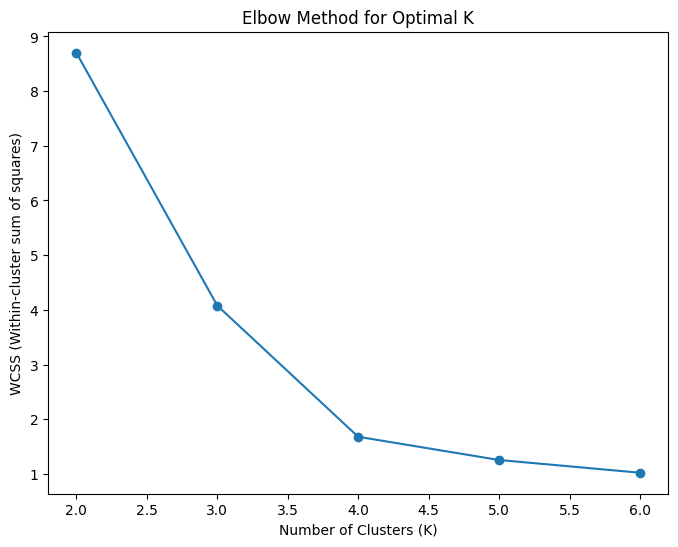

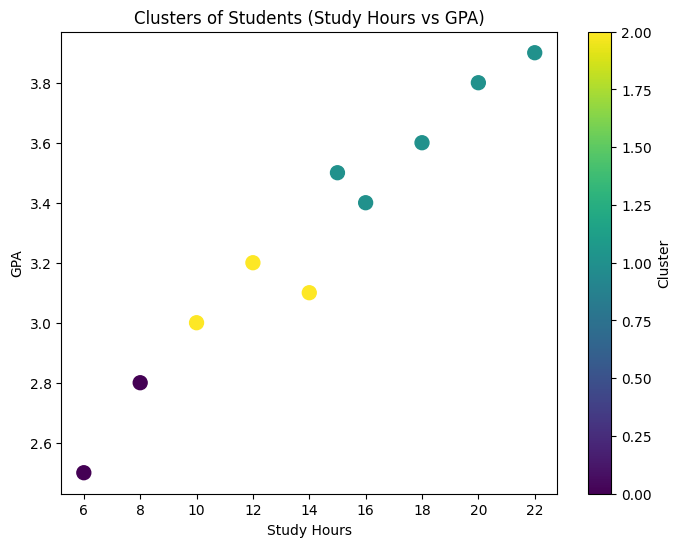

   student_id  cluster
0           1        1
1           2        2
2           3        1
3           4        0
4           5        2
5           6        1
6           7        1
7           8        0
8           9        2
9          10        1


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'student_id': range(1, 11),
    'GPA': [3.5, 3.0, 3.8, 2.8, 3.2, 3.6, 3.9, 2.5, 3.1, 3.4],
    'study_hours': [15, 10, 20, 8, 12, 18, 22, 6, 14, 16],
    'attendance_rate': [90, 85, 95, 75, 80, 92, 96, 70, 84, 89]
}

df = pd.DataFrame(data)
features = df[['GPA', 'study_hours', 'attendance_rate']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

wcss = []
for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 7), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-cluster sum of squares)')
plt.show()

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(features_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(df['study_hours'], df['GPA'], c=df['cluster'], cmap='viridis', s=100)
plt.title('Clusters of Students (Study Hours vs GPA)')
plt.xlabel('Study Hours')
plt.ylabel('GPA')
plt.colorbar(label='Cluster')
plt.show()

print(df[['student_id', 'cluster']])
